In [29]:
#todos los imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [64]:
df = pd.read_csv("Titanic.csv") # Cargar el dataset
# Verificar duplicados en PassengerId
duplicados = df[df["PassengerId"].duplicated(keep=False)]

if duplicados.empty:
    print("No hay duplicados en PassengerId.")
else:
    print(f"Se encontraron {duplicados.shape[0]} duplicados en PassengerId:")
    display(duplicados)

# Verificar filas duplicadas completas
print("Cantidad de filas duplicadas en el dataset:", df.duplicated().sum())
df = df.drop_duplicates()  # Eliminar filas duplicadas
print("Filas duplicadas eliminadas. Nueva cantidad de filas:", df.shape[0])


#Eliminar columnas irrelevantes (texto libre o identificadores únicos)
cols_to_drop = ["PassengerId", "Name", "Ticket", "Cabin"]
df = df.drop(columns=cols_to_drop)
print("Columnas eliminadas:", cols_to_drop)

#Rango de datos para ver si esta todo noraml o hay tarifas ridiculas o edades negativas
print("\nRangos básicos de variables:")
print("Edad mínima:", df["Age"].min(), "Edad máxima:", df["Age"].max())
print("Tarifa mínima:", df["Fare"].min(), "Tarifa máxima:", df["Fare"].max())


# Verificar valores faltantes por columna
print("\nValores faltantes por columna:")
print(df.isna().sum())

#Imputar valores faltantes
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

#Confirmar que no queden valores nulos
print("\nValores faltantes después de imputar:")
print(df.isna().sum())

#Convertir variables categóricas a numéricas con One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

#Dimensiones del dataset
print("Dimensiones del dataset:", df.shape) 
df.head()


print("Columnas del dataset:")
print(df.columns)
print("\nTipos de datos:")
print(df.dtypes)


No hay duplicados en PassengerId.
Cantidad de filas duplicadas en el dataset: 0
Filas duplicadas eliminadas. Nueva cantidad de filas: 891
Columnas eliminadas: ['PassengerId', 'Name', 'Ticket', 'Cabin']

Rangos básicos de variables:
Edad mínima: 0.42 Edad máxima: 80.0
Tarifa mínima: 0.0 Tarifa máxima: 512.3292

Valores faltantes por columna:
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

Valores faltantes después de imputar:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
Dimensiones del dataset: (891, 9)
Columnas del dataset:
Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

Tipos de datos:
Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male       

## Matriz de correlación
Antes de aplicar PCA, es útil observar la matriz de correlación para identificar relaciones entre variables y justificar la reducción de dimensionalidad.

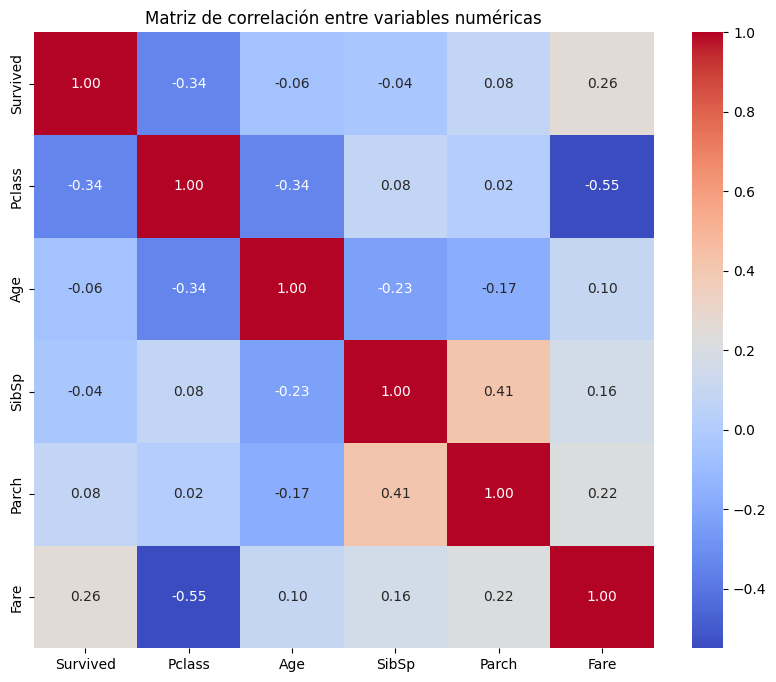

In [65]:
# Seleccionar solo las columnas numéricas
df_num = df.select_dtypes(include=['number'])

# Calcular la matriz de correlación solo con variables numéricas
corr = df_num.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

Escalado exitoso. Forma de X_scaled: (891, 8)


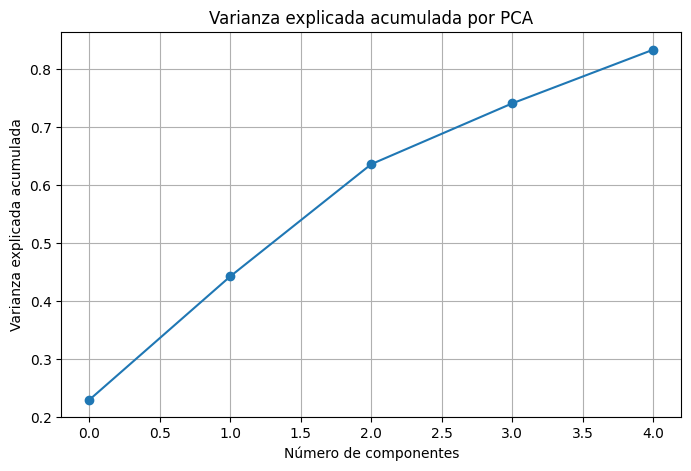

In [57]:
# Gráfica de varianza explicada acumulada

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Escalado exitoso. Forma de X_scaled:", X_scaled.shape)

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada por PCA')
plt.grid(True)
plt.show()

## Varianza explicada acumulada
La gráfica de varianza explicada acumulada permite decidir cuántos componentes principales son necesarios para representar la mayor parte de la información del dataset.

In [ ]:
# Quitamos texto irrelevante y la columna objetivo
cols_to_drop = ["Name", "Ticket", "Cabin"]  # texto libre
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Separar variable objetivo (no se normaliza porque no participa del PCA)
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Reemplazar valores faltantes
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

print("Forma final de X (despues de limpiar):", X.shape)
X.head()


Forma final de X (despues de limpiar): (891, 8)


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [58]:
pca = PCA(n_components=5)  # 5 componentes para analizar
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
varianza = pca.explained_variance_ratio_
print("Varianza explicada por PC1:", round(varianza[0]*100,2), "%")
print("Varianza explicada por PC2:", round(varianza[1]*100,2), "%")
print("Varianza total (PC1+PC2):", round((varianza[0]+varianza[1])*100,2), "%")


Varianza explicada por PC1: 23.0 %
Varianza explicada por PC2: 21.3 %
Varianza total (PC1+PC2): 44.3 %


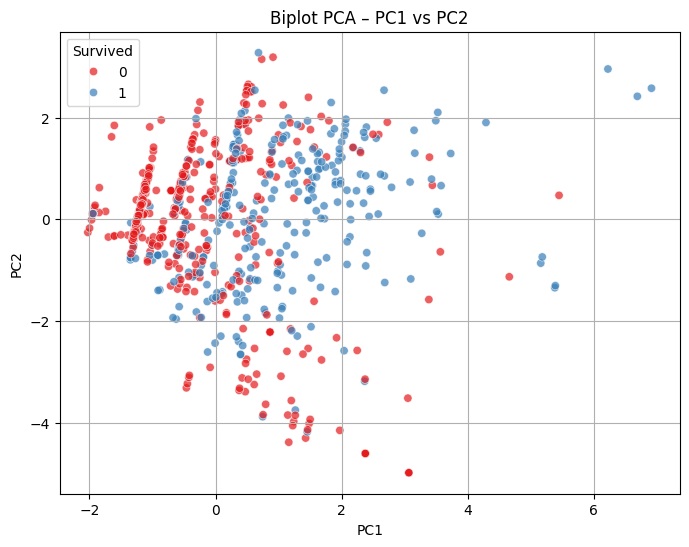

In [59]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette="Set1", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Biplot PCA – PC1 vs PC2")
plt.legend(title="Survived")
plt.grid(True)
plt.show()


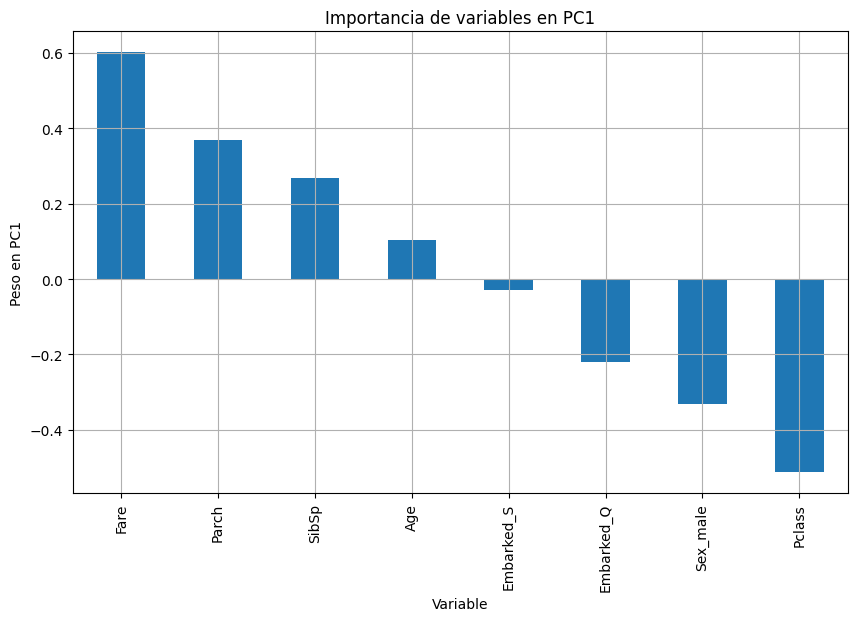

In [54]:
# Gráfica de importancia de variables en PC1
pc1_importancia = pd.Series(pca.components_[0], index=X.columns).sort_values(ascending=False)
pc1_importancia.plot(kind='bar', figsize=(10,6))
plt.title('Importancia de variables en PC1')
plt.ylabel('Peso en PC1')
plt.xlabel('Variable')
plt.grid(True)
plt.show()

## Importancia de variables en PC1
A continuación se muestra la importancia de cada variable en la primera componente principal (PC1), lo que permite identificar cuáles influyen más en la variabilidad de los datos.

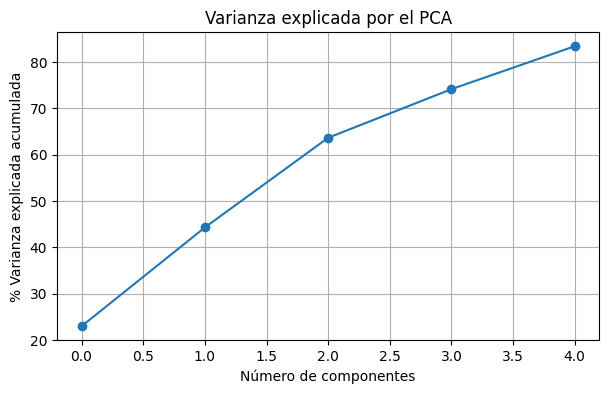

In [60]:
plt.figure(figsize=(7,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100, marker="o")
plt.xlabel("Número de componentes")
plt.ylabel("% Varianza explicada acumulada")
plt.title("Varianza explicada por el PCA")
plt.grid(True)
plt.show()


In [45]:
pc1_importancia = pd.Series(abs(pca.components_[0]), index=X.columns)
pc1_importancia = pc1_importancia.sort_values(ascending=False)

print("Top variables que más influyen en PC1:")
print(pc1_importancia.head(10))


Top variables que más influyen en PC1:
Fare          0.600778
Pclass        0.512372
Parch         0.369539
Sex_male      0.330039
SibSp         0.266860
Embarked_Q    0.219900
Age           0.103034
Embarked_S    0.029498
dtype: float64
